# Factor Data

Factor data describes systematic drivers of returns such as market exposure, size, value, quality, momentum, and low volatility.

Abbreviations used in this notebook:

- **CAPM**: Capital Asset Pricing Model.
- **MKT**: Market factor, broad equity market return minus the risk-free rate.
- **SMB**: Small Minus Big, a size factor.
- **HML**: High Minus Low, a value factor.
- **MOM**: Momentum factor.
- **RMW**: Robust Minus Weak, a profitability or quality factor.
- **CMA**: Conservative Minus Aggressive, an investment factor.
- **OLS**: Ordinary Least Squares regression.
- **CHF**: Swiss franc, the currency used in examples where needed.

## 1. Intuition

A stock return can be decomposed into exposure to broad forces. A defensive consumer staples company may have lower market beta, positive quality exposure, and lower volatility than the average stock.

Factor analysis helps answer: did the stock outperform because of company-specific skill, or because it was exposed to rewarded factors?

## 2. Mathematics

Single-factor CAPM model:

$$
R_i - R_f = \alpha + \beta_m(R_m - R_f) + \epsilon
$$

Multi-factor model:

$$
R_i - R_f = \alpha + \beta_m MKT + \beta_s SMB + \beta_v HML + \beta_q RMW + \beta_mom MOM + \epsilon
$$

Where:

- $\alpha$ = unexplained excess return.
- $\beta$ = sensitivity to a factor.
- $\epsilon$ = residual return not explained by the model.

## 3. Implementation

We will create synthetic daily factor returns and a synthetic stock return series with known exposures, then estimate those exposures with linear regression.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(33)

dates = pd.bdate_range("2024-01-02", periods=252)
factors = pd.DataFrame({
    "date": dates,
    "risk_free": np.random.normal(0.00005, 0.00001, len(dates)),
    "market": np.random.normal(0.00030, 0.0090, len(dates)),
    "smb": np.random.normal(0.00002, 0.0045, len(dates)),
    "hml": np.random.normal(0.00004, 0.0040, len(dates)),
    "rmw": np.random.normal(0.00003, 0.0035, len(dates)),
    "mom": np.random.normal(0.00005, 0.0050, len(dates)),
})

true_betas = {
    "market": 0.72,
    "smb": -0.15,
    "hml": 0.10,
    "rmw": 0.28,
    "mom": 0.08,
}

noise = np.random.normal(0, 0.004, len(dates))
factors["stock_excess_return"] = sum(factors[name] * beta for name, beta in true_betas.items()) + noise
factors["stock_return"] = factors["risk_free"] + factors["stock_excess_return"]

factors.head()

,date,risk_free,market,smb,hml,rmw,mom,stock_excess_return,stock_return
0,2024-01-02,0.000047,0.033926,0.003880,-0.005424,0.002583,0.001265,0.012716,0.012763
1,2024-01-03,0.000034,0.007970,-0.002783,-0.002477,-0.002485,-0.007162,0.005018,0.005052
2,2024-01-04,0.000035,0.004762,-0.003675,0.005397,0.002188,0.002223,-0.007357,-0.007323
3,2024-01-05,0.000044,0.003727,0.006684,-0.000295,-0.004000,0.003747,0.006967,0.007012
4,2024-01-08,0.000048,0.003546,0.000465,0.000951,0.005945,0.004829,-0.003039,-0.002992


In [2]:
def ols_regression(y, x):
    x_matrix = np.column_stack([np.ones(len(x)), x])
    coefficients = np.linalg.lstsq(x_matrix, y, rcond=None)[0]
    fitted = x_matrix @ coefficients
    residuals = y - fitted
    r_squared = 1 - (residuals @ residuals) / ((y - y.mean()) @ (y - y.mean()))
    return coefficients, fitted, residuals, r_squared

factor_columns = ["market", "smb", "hml", "rmw", "mom"]
y = factors["stock_excess_return"].to_numpy()
x = factors[factor_columns].to_numpy()
coefficients, fitted, residuals, r_squared = ols_regression(y, x)

estimated = pd.Series(coefficients[1:], index=factor_columns, name="estimated_beta")
true = pd.Series(true_betas, name="true_beta")
exposures = pd.concat([true, estimated], axis=1)

print(f"Estimated daily alpha: {coefficients[0]:.5f}")
print(f"R-squared: {r_squared:.1%}")
exposures.round(3)

Estimated daily alpha: -0.00014
R-squared: 70.7%


,true_beta,estimated_beta
market,0.72,0.687
smb,-0.15,-0.062
hml,0.10,0.111
rmw,0.28,0.243
mom,0.08,0.131


## 4. Visualization

Factor charts show whether estimated exposures align with the synthetic truth and which factors contributed most to return.

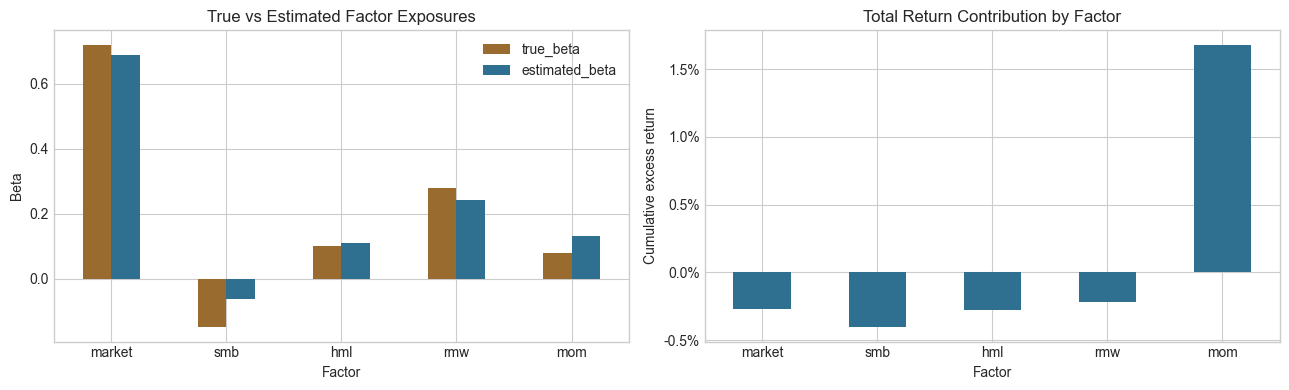

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

exposures.plot(kind="bar", ax=axes[0], color=["#9a6b2f", "#2f6f8f"])
axes[0].set_title("True vs Estimated Factor Exposures")
axes[0].set_xlabel("Factor")
axes[0].set_ylabel("Beta")
axes[0].tick_params(axis="x", rotation=0)

factor_contribution = factors[factor_columns].multiply(estimated, axis=1).sum()
factor_contribution.plot(kind="bar", ax=axes[1], color="#2f6f8f")
axes[1].set_title("Total Return Contribution by Factor")
axes[1].set_xlabel("Factor")
axes[1].set_ylabel("Cumulative excess return")
axes[1].tick_params(axis="x", rotation=0)
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")

plt.tight_layout()
plt.show()

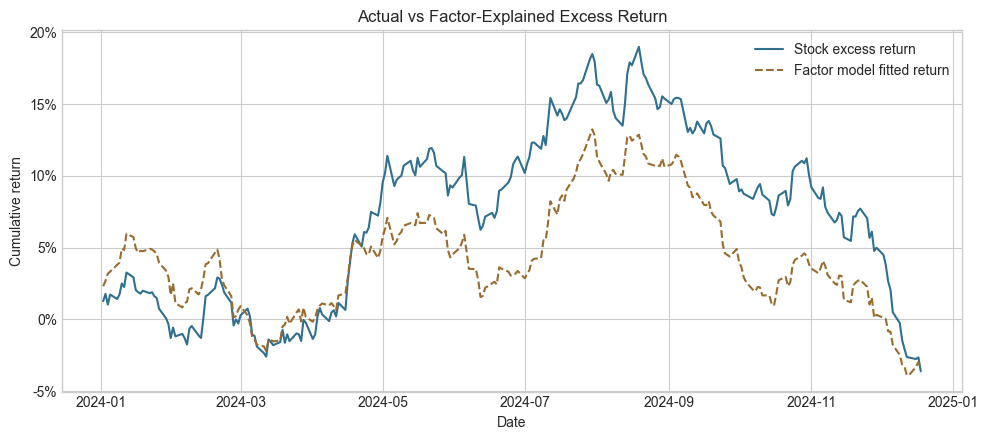

In [4]:
factors["fitted_excess_return"] = fitted
factors["cumulative_stock_excess"] = (1 + factors["stock_excess_return"]).cumprod() - 1
factors["cumulative_fitted_excess"] = (1 + factors["fitted_excess_return"]).cumprod() - 1

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(factors["date"], factors["cumulative_stock_excess"], color="#2f6f8f", label="Stock excess return")
ax.plot(factors["date"], factors["cumulative_fitted_excess"], color="#9a6b2f", linestyle="--", label="Factor model fitted return")
ax.set_title("Actual vs Factor-Explained Excess Return")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Application

Factor data is useful for risk attribution, portfolio construction, manager evaluation, and strategy design. If a strategy performs well only because it loads on known factors, that is different from producing unique alpha.

In later portfolio notebooks, factor exposures can help explain why a portfolio behaves the way it does under different market regimes.

In [5]:
risk_summary = pd.Series({
    "annualized_stock_volatility": factors["stock_return"].std() * np.sqrt(252),
    "annualized_market_volatility": factors["market"].std() * np.sqrt(252),
    "estimated_market_beta": estimated["market"],
    "model_r_squared": r_squared,
    "annualized_alpha_approx": coefficients[0] * 252,
})

risk_summary.to_frame("value")

,value
annualized_stock_volatility,0.117499
annualized_market_volatility,0.141030
estimated_market_beta,0.686894
model_r_squared,0.706929
annualized_alpha_approx,-0.035033


## 6. Reflection

- Factor models explain returns through systematic exposures.
- Beta measures sensitivity, not guaranteed future performance.
- Alpha is the return left unexplained by the chosen factors.
- Factor data is only useful if definitions, timing, and data quality are consistent.

Questions to answer after running the notebook:

1. Why might a defensive company have market beta below 1?
2. What does positive quality exposure mean conceptually?
3. Why is alpha harder to trust when R-squared is low?
4. How could factor exposure help with portfolio risk management?